In [ ]:
df <- read.csv('pam_bank_cardholders.csv')

dim_info <- dim(df)
cat('Number of rows:', dim_info[1], '\n')
cat('Number of columns:', dim_info[2], '\n')

total_na <- sum(is.na(df))
cat('Total missing values:', total_na, '\n')

cat('\nMissing values per column:\n')
print(colSums(is.na(df)))

Number of rows: 76 
Number of columns: 5 
Total missing values: 0 

Missing values per column:
       cardholder_id monthly_transactions       monthly_income 
                   0                    0                    0 
        tenure_years   credit_utilization 
                   0                    0 


In [ ]:
print(summary(df))

 cardholder_id      monthly_transactions monthly_income    tenure_years   
 Length:76          Min.   : 2.00        Min.   : 21000   Min.   : 1.000  
 Class :character   1st Qu.:14.00        1st Qu.: 45514   1st Qu.: 5.000  
 Mode  :character   Median :19.00        Median : 94498   Median : 8.000  
                    Mean   :25.51        Mean   : 97726   Mean   : 7.421  
                    3rd Qu.:41.00        3rd Qu.:144356   3rd Qu.:10.000  
                    Max.   :70.00        Max.   :320000   Max.   :18.000  
 credit_utilization
 Min.   : 2.00     
 1st Qu.:21.00     
 Median :32.50     
 Mean   :34.51     
 3rd Qu.:44.25     
 Max.   :96.00     


In [ ]:
numeric_cols <- sapply(df, is.numeric)
numeric_df <- df[, numeric_cols]

In [ ]:
for (col_name in names(numeric_df)) {
  data_vec <- numeric_df[[col_name]]
  std_dev <- sd(data_vec, na.rm = TRUE)
  iqr_val <- IQR(data_vec, na.rm = TRUE)
  outliers <- boxplot.stats(data_vec)$out
  cat(paste0('Variable: ', col_name, '\n'))
  cat(paste0('  Standard Deviation: ', round(std_dev, 2), '\n'))
  cat(paste0('  Interquartile Range: ', round(iqr_val, 2), '\n'))
}

Variable: monthly_transactions
  Standard Deviation: 15.54
  Interquartile Range: 27
Variable: monthly_income
  Standard Deviation: 57913.1
  Interquartile Range: 98841.75
Variable: tenure_years
  Standard Deviation: 3.84
  Interquartile Range: 5
Variable: credit_utilization
  Standard Deviation: 19.21
  Interquartile Range: 23.25


In [ ]:
cor_matrix <- cor(numeric_df, use = "complete.obs")
print(round(cor_matrix, 3))
cor_tri <- cor_matrix
diag(cor_tri) <- 0
max_cor_val <- max(abs(cor_tri))
indices <- which(abs(cor_tri) == max_cor_val, arr.ind = TRUE)
var1 <- rownames(cor_tri)[indices[1,1]]
var2 <- colnames(cor_tri)[indices[1,2]]

cat(paste0('The strongest relationship is between "', var1, '" and "', var2, '", correlation : ', round(cor_matrix[var1, var2], 4)))

                     monthly_transactions monthly_income tenure_years
monthly_transactions                1.000         -0.245       -0.525
monthly_income                     -0.245          1.000        0.229
tenure_years                       -0.525          0.229        1.000
credit_utilization                  0.701         -0.107       -0.386
                     credit_utilization
monthly_transactions              0.701
monthly_income                   -0.107
tenure_years                     -0.386
credit_utilization                1.000
The strongest relationship is between "credit_utilization" and "monthly_transactions", correlation :0.7009.

Warning message in element_text(rotation = 45, hjust = 1):
“`...` must be empty.
✖ Problematic argument:
• rotation = 45”
`geom_smooth()` using formula = 'y ~ x'


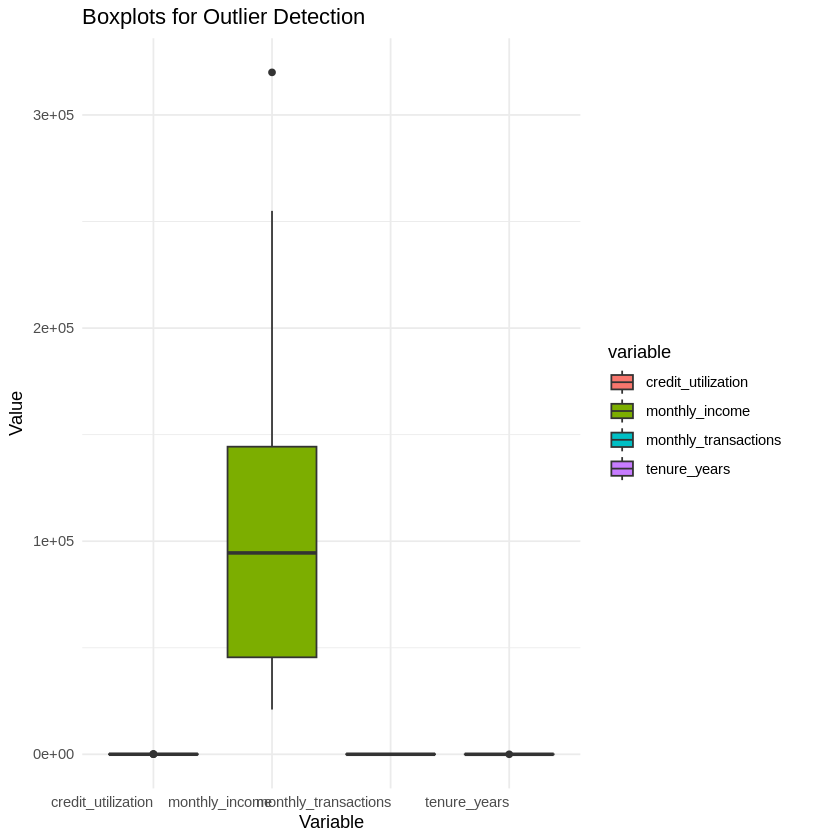

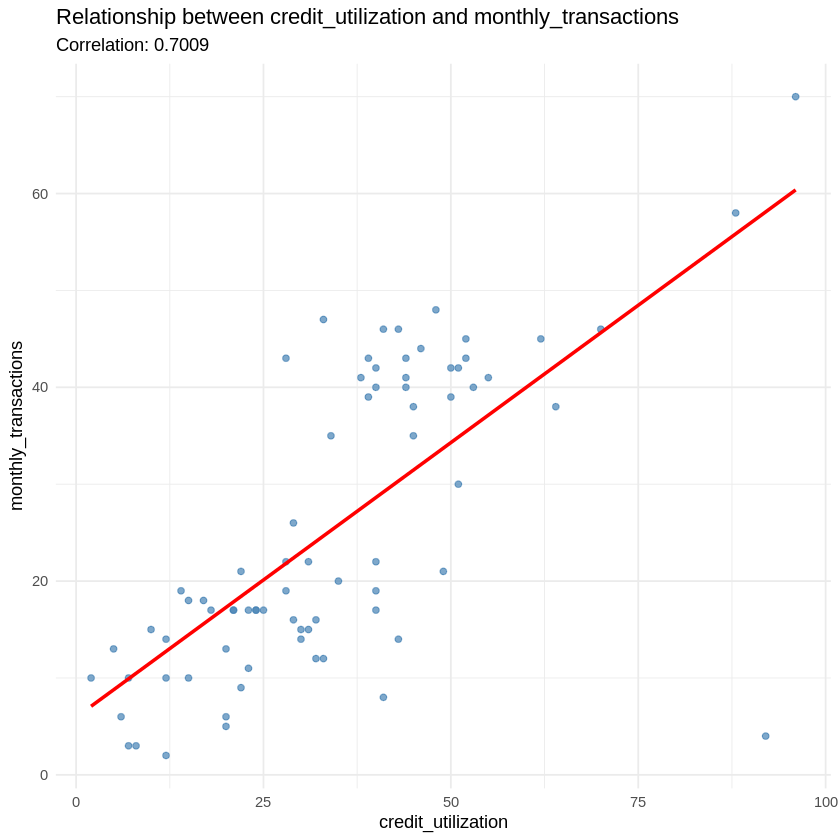

In [ ]:
library(ggplot2)
library(tidyr)

numeric_df_long <- pivot_longer(numeric_df, cols = everything(), names_to = "variable", values_to = "value")

boxplot_plot <- ggplot(numeric_df_long, aes(x = variable, y = value, fill = variable)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Boxplots for Outlier Detection", x = "Variable", y = "Value") +
  theme(axis.text.x = element_text(rotation = 45, hjust = 1))

print(boxplot_plot)


scatter_plot <- ggplot(df, aes_string(x = var1, y = var2)) +
  geom_point(color = "steelblue", alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  theme_minimal() +
  labs(title = paste("Relationship between", var1, "and", var2),
       subtitle = paste("Correlation:", round(cor_matrix[var1, var2], 4)),
       x = var1, y = var2)

print(scatter_plot)

In [ ]:
scaled_df <- scale(numeric_df)
library(cluster)
k_values <- 2:6
sil_widths <- numeric(length(k_values))
for (i in seq_along(k_values)) {
  k <- k_values[i]
  pam_fit <- pam(scaled_df, k = k)
  sil_widths[i] <- pam_fit$silinfo$avg.width
}
pam_results <- data.frame(k = k_values, avg_silhouette_width = sil_widths)
print(pam_results)
best_k <- pam_results$k[which.max(pam_results$avg_silhouette_width)]
cat('\nOptimal number of clusters (k):', best_k, '\n')

  k avg_silhouette_width
1 2            0.4069779
2 3            0.4766829
3 4            0.4264089
4 5            0.4316189
5 6            0.3783640

Optimal number of clusters (k): 3 


In [ ]:
final_pam <- pam(scaled_df, k = best_k)
medoid_indices <- final_pam$id.med
medoids <- df[medoid_indices, ]
print(medoids)
df$cluster <- as.factor(final_pam$clustering)
cluster_profile <- aggregate(numeric_df, by = list(Cluster = df$cluster), FUN = mean)
cat('\nCluster Profiles (Means)\n')
print(cluster_profile)
cat('\nCluster Sizes\n')
print(table(df$cluster))

   cardholder_id monthly_transactions monthly_income tenure_years
23          B023                   22          45450            8
31          B031                   43         110899            5
66          B066                   10         165289           12
   credit_utilization cluster
23                 31       1
31                 52       2
66                 12       3

Cluster Profiles (Means)
  Cluster monthly_transactions monthly_income tenure_years credit_utilization
1       1             17.55556       42719.59     7.888889           28.81481
2       2             42.13333      102259.53     4.600000           50.86667
3       3             10.57895      168735.32    11.210526           16.78947

Cluster Sizes

 1  2  3 
27 30 19 
